# Volume Profile + CVD Absorption Strategy – v7 (POC Entries)

真實 BTCUSDT 數據 · 5 日 Composite Profile + 前一日 VAL/VAH/POC · CVD 吸收/力竭檢測
**Entry at POC**: absorption → LONG, exhaustion → SHORT (both directions at POC).

In [1]:
import io, zipfile, warnings, time, math
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from dataclasses import dataclass, field
from nautilus_trader.test_kit.providers import TestInstrumentProvider

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi':120,'figure.figsize':(14,5)})
INSTRUMENT = TestInstrumentProvider.btcusdt_perp_binance()
TICK_SIZE, VA_PCT = 0.1, 0.70

PROFILE_DAYS = ['2024-03-04','2024-03-05','2024-03-06','2024-03-07','2024-03-08']
TEST_DAYS    = ['2024-03-11','2024-03-12','2024-03-13','2024-03-14','2024-03-15']

ACCOUNT_BALANCE  = 100_000.0   # USDT
RISK_PER_TRADE   = 0.02        # 2%
STOP_LOSS_PCT    = 0.02
TOUCH_BUFFER     = 0.002       # 0.2%  proximity to POC for entry
MIN_IMBALANCE    = 1.2
MIN_DELTA_RATIO  = 0.02
BREAKEVEN_PCT    = 0.005       # 0.5% → breakeven
CVD_LOOKBACK     = 5

print(f'Profile: {PROFILE_DAYS[0]}..{PROFILE_DAYS[-1]}  Test: {TEST_DAYS[0]}..{TEST_DAYS[-1]}')
print(f'Risk: {RISK_PER_TRADE*100:.0f}% account ({ACCOUNT_BALANCE*RISK_PER_TRADE:.0f} USDT/trade)')
print(f'Entry: at POC +/- {TOUCH_BUFFER*100:.1f}% | Targets: VAH/L of prior day')

C:\Users\cyt\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Profile: 2024-03-04..2024-03-08  Test: 2024-03-11..2024-03-15
Risk: 2% account (2000 USDT/trade)
Entry: at POC +/- 0.2% | Targets: VAH/L of prior day


In [2]:
# === Download ===
CACHE = {}
def dl(data_type, date):
    k=(data_type,date)
    if k in CACHE: return CACHE[k]
    url=f'https://data.binance.vision/data/futures/um/daily/{data_type}/BTCUSDT/BTCUSDT-{data_type}-{date}.zip'
    r=requests.get(url); r.raise_for_status()
    CACHE[k]=r.content; return r.content

def rd_agg(date):
    z=zipfile.ZipFile(io.BytesIO(dl('aggTrades',date)))
    c=[n for n in z.namelist() if n.endswith('.csv')][0]
    return pd.read_csv(z.open(c))

def rd_bk(date, sample=50):
    z=zipfile.ZipFile(io.BytesIO(dl('bookTicker',date)))
    c=[n for n in z.namelist() if n.endswith('.csv')][0]
    return pd.read_csv(z.open(c), skiprows=lambda i: i>0 and i%sample!=0)

print('Helper ready.')

Helper ready.


In [3]:
# === Profile Calculator ===
@dataclass
class DayProfile:
    date:str; poc:float; vah:float; val:float
    total_volume:float; price_levels:dict=field(repr=False)

def calc_profile(df):
    df=df.copy(); df['b']=np.round(df['price']/TICK_SIZE)*TICK_SIZE
    vp=df.groupby('b')['quantity'].sum(); tv=vp.sum(); poc=vp.idxmax()
    levels=vp.sort_index(); idx=list(levels.index); pp=idx.index(poc)
    cv=levels.iloc[pp]; inc={poc}; t=tv*VA_PCT; l,r=pp-1,pp+1
    while cv<t and (l>=0 or r<len(idx)):
        vl=levels.iloc[l] if l>=0 else 0; vr=levels.iloc[r] if r<len(idx) else 0
        if vl>=vr and l>=0: inc.add(idx[l]); cv+=vl; l-=1
        elif r<len(idx): inc.add(idx[r]); cv+=vr; r+=1
        else: break
    ds=pd.Timestamp(df['transact_time'].iloc[0],unit='ms').strftime('%Y-%m-%d')
    return DayProfile(date=ds,poc=poc,vah=max(inc),val=min(inc),total_volume=tv,price_levels=vp.to_dict())

t0=time.time()
comp_vp={}; comp_tv=0; day_profs={}
for d in PROFILE_DAYS:
    print(f'Profile {d}...',end=' ')
    df=rd_agg(d); p=calc_profile(df)
    day_profs[d]=p; comp_tv+=p.total_volume
    for px,v in p.price_levels.items(): comp_vp[px]=comp_vp.get(px,0)+v
    print(f'{len(df):,}t VAL={p.val:.0f} POC={p.poc:.0f} VAH={p.vah:.0f}'); del df

cp=max(comp_vp,key=comp_vp.get); sp=sorted(comp_vp.keys()); pp=sp.index(cp)
cv=comp_vp[cp]; inc={cp}; l,r=pp-1,pp+1
while cv<comp_tv*VA_PCT and (l>=0 or r<len(sp)):
    vl=comp_vp[sp[l]] if l>=0 else 0; vr=comp_vp[sp[r]] if r<len(sp) else 0
    if vl>=vr and l>=0: inc.add(sp[l]); cv+=vl; l-=1
    elif r<len(sp): inc.add(sp[r]); cv+=vr; r+=1
    else: break
COMP_VAL, COMP_VAH, COMP_POC = min(inc), max(inc), cp
print(f'\nComposite: VAL={COMP_VAL:.0f} POC={COMP_POC:.0f} VAH={COMP_VAH:.0f} ({time.time()-t0:.0f}s)')

Profile 2024-03-04... 

3,043,615t VAL=64584 POC=65000 VAH=67800
Profile 2024-03-05... 

5,270,260t VAL=61610 POC=63300 VAH=67300
Profile 2024-03-06... 

3,092,594t VAL=65856 POC=66000 VAH=67416
Profile 2024-03-07... 

1,794,188t VAL=66675 POC=67000 VAH=67866
Profile 2024-03-08... 

2,606,144t VAL=67098 POC=68000 VAH=68959

Composite: VAL=65196 POC=67000 VAH=68797 (26s)


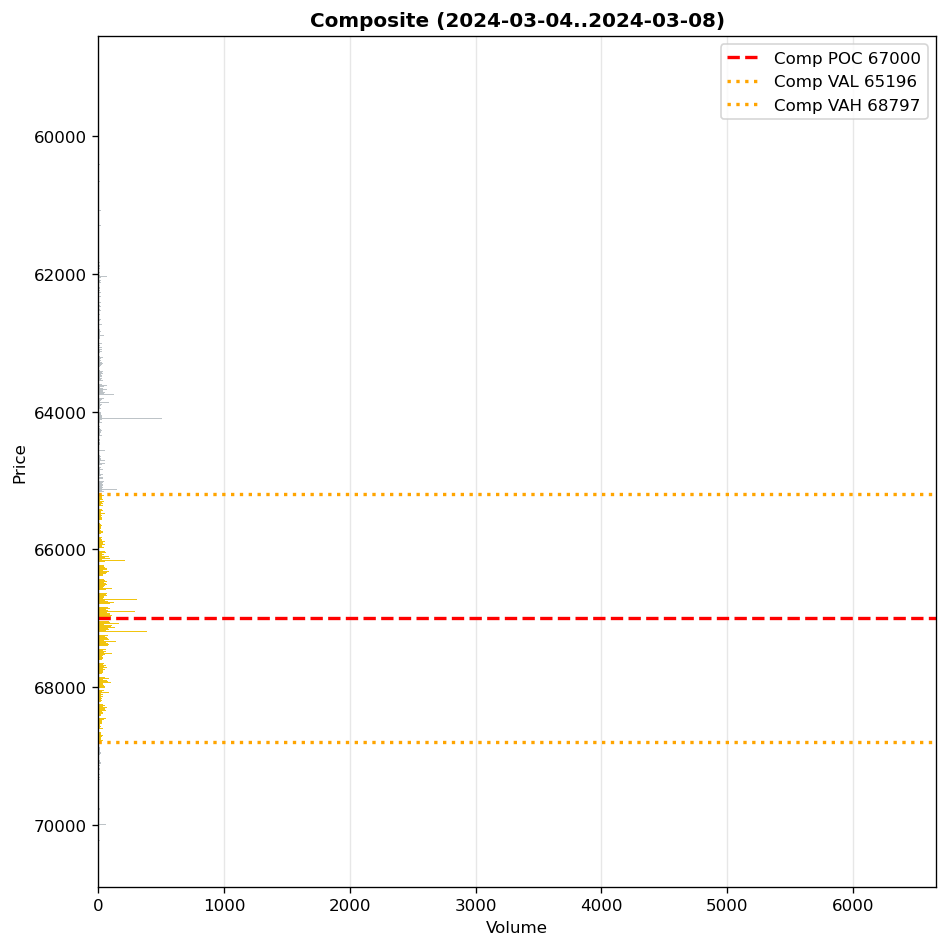

Composite: VAL=65196  POC=67000  VAH=68797
Day profiles:
  2024-03-04: VAL=64584 POC=65000 VAH=67800
  2024-03-05: VAL=61610 POC=63300 VAH=67300
  2024-03-06: VAL=65856 POC=66000 VAH=67416
  2024-03-07: VAL=66675 POC=67000 VAH=67866
  2024-03-08: VAL=67098 POC=68000 VAH=68959


In [4]:
# === Profile Chart ===
fig,ax=plt.subplots(figsize=(8,8))
sp=sorted(comp_vp.keys()); vl=[comp_vp[px] for px in sp]
cl=['#e74c3c' if px==COMP_POC else '#f1c40f' if COMP_VAL<=px<=COMP_VAH else '#bdc3c7' for px in sp]
ax.barh(sp,vl,height=TICK_SIZE*0.8,color=cl,ec='none')
ax.axhline(COMP_POC,color='red',lw=2,ls='--',label=f'Comp POC {COMP_POC:.0f}')
ax.axhline(COMP_VAL,color='orange',lw=2,ls=':',label=f'Comp VAL {COMP_VAL:.0f}')
ax.axhline(COMP_VAH,color='orange',lw=2,ls=':',label=f'Comp VAH {COMP_VAH:.0f}')
ax.invert_yaxis(); ax.legend(); ax.set_xlabel('Volume'); ax.set_ylabel('Price')
ax.set_title(f'Composite ({PROFILE_DAYS[0]}..{PROFILE_DAYS[-1]})',fontweight='bold'); ax.grid(alpha=0.3,axis='x')
plt.tight_layout(); plt.show()

print(f'Composite: VAL={COMP_VAL:.0f}  POC={COMP_POC:.0f}  VAH={COMP_VAH:.0f}')
print(f'Day profiles:')
for d in PROFILE_DAYS:
    p=day_profs[d]; print(f'  {d}: VAL={p.val:.0f} POC={p.poc:.0f} VAH={p.vah:.0f}')

In [5]:
# === Strategy: POC-based entries with CVD divergence + Dynamic Risk ===
class Strategy:
    def __init__(self, prior_val, prior_vah, prior_poc):
        self.prior_val=prior_val; self.prior_vah=prior_vah; self.prior_poc=prior_poc
        self.side=None; self.entry_px=None; self.stop_px=None; self.size=0
        self.entry_ts=None
        self.bar_open=None; self.bar_close_px=None; self.bar_high=None; self.bar_low=None
        self.bar_vol=self.bar_buy=self.bar_sell=0; self.bar_count=0
        self.quotes_buf=[]; self.trades_log=[]
        self.bar_deltas=[]; self.cvd_history=[]; self.bar_lows=[]; self.bar_highs=[]
        self.cvd=0.0

    def on_quote(self,bp,ap,bq,aq):
        self.quotes_buf.append((bp,ap,bq,aq))
        if len(self.quotes_buf)>100: self.quotes_buf.pop(0)

    def on_trade(self,price,qty,is_buyer_maker,ts):
        if self.bar_open is None:
            self.bar_open=self.bar_high=self.bar_low=price; self.bar_ts=ts
        self.bar_high=max(self.bar_high,price)
        self.bar_low=min(self.bar_low,price)
        self.bar_close_px=price
        self.bar_vol+=qty
        if not is_buyer_maker: self.bar_buy+=qty
        else: self.bar_sell+=qty
        self.bar_count+=1

    def on_bar_close(self,ts=None):
        if self.bar_open is None: return
        close=self.bar_close_px
        delta=self.bar_buy-self.bar_sell
        total=self.bar_buy+self.bar_sell
        dr=delta/total if total>0 else 0
        
        self.cvd+=delta
        self.cvd_history.append(self.cvd)
        self.bar_deltas.append(delta)
        self.bar_lows.append(self.bar_low)
        self.bar_highs.append(self.bar_high)
        if len(self.bar_lows)>CVD_LOOKBACK*2:
            self.bar_lows.pop(0); self.bar_highs.pop(0); self.cvd_history.pop(0); self.bar_deltas.pop(0)

        if self.side is None:
            self._try_entry(close,dr,total,ts)
        else:
            self._check_exit(close,ts)

        self.bar_open=None; self.bar_close_px=None; self.bar_high=None; self.bar_low=None
        self.bar_vol=self.bar_buy=self.bar_sell=0; self.bar_count=0

    def _imbalance(self,favor_buy=True):
        if len(self.quotes_buf)<3: return 0.0
        rs=[]
        for _,_,bq,aq in self.quotes_buf[-10:]:
            if bq>0 and aq>0: rs.append(bq/aq if favor_buy else aq/bq)
        return float(np.mean(rs)) if rs else 0.0

    def _cvd_divergence(self,check_bullish=True):
        # Bullish: price new low but CVD not → absorption (reversal up)
        # Bearish: price new high but CVD not → exhaustion (reversal down)
        if len(self.bar_lows)<CVD_LOOKBACK+1: return False
        recent_lows=self.bar_lows[-(CVD_LOOKBACK+1):]
        recent_cvd=self.cvd_history[-(CVD_LOOKBACK+1):]
        if check_bullish:
            if self.bar_low<min(recent_lows[:-1]):
                if self.cvd>=min(recent_cvd[:-1]):
                    return True
        else:
            if self.bar_high>max(self.bar_highs[-(CVD_LOOKBACK+1):-1]):
                if self.cvd<=max(recent_cvd[:-1]):
                    return True
        return False

    def _try_entry(self,price,dr,total,ts):
        # Both directions at prior day POC. Direction determined by CVD divergence.
        near_poc = abs(price - self.prior_poc) / self.prior_poc <= TOUCH_BUFFER
        if not near_poc:
            return

        absorption = self._cvd_divergence(check_bullish=True)
        exhaustion = self._cvd_divergence(check_bullish=False)

        # Absorption at POC → LONG
        if absorption and dr > MIN_DELTA_RATIO and self._imbalance(favor_buy=True) >= MIN_IMBALANCE:
            self.side='LONG'; self.entry_px=price; self.entry_ts=ts
            ab_low=self.bar_low*0.997
            fixed_stop=price*(1-STOP_LOSS_PCT)
            self.stop_px=min(ab_low,fixed_stop)
            risk_per_unit=price-self.stop_px
            self.size=ACCOUNT_BALANCE*RISK_PER_TRADE/risk_per_unit if risk_per_unit>0 else 0.01
            print(f'>>> LONG @ POC {price:.1f} stop={self.stop_px:.1f} size={self.size:.3f} '
                  f'd={dr:.3f} imb={self._imbalance(True):.1f} absorption={absorption}')

        # Exhaustion at POC → SHORT
        if exhaustion and dr < -MIN_DELTA_RATIO and self._imbalance(favor_buy=False) >= MIN_IMBALANCE:
            self.side='SHORT'; self.entry_px=price; self.entry_ts=ts
            ab_high=self.bar_high*1.003
            fixed_stop=price*(1+STOP_LOSS_PCT)
            self.stop_px=max(ab_high,fixed_stop)
            risk_per_unit=self.stop_px-price
            self.size=ACCOUNT_BALANCE*RISK_PER_TRADE/risk_per_unit if risk_per_unit>0 else 0.01
            print(f'>>> SHORT @ POC {price:.1f} stop={self.stop_px:.1f} size={self.size:.3f} '
                  f'd={dr:.3f} imb={self._imbalance(False):.1f} exhaustion={exhaustion}')

    def _check_exit(self,price,ts):
        # Exit: stop loss, breakeven, or target VAH/L.
        if self.side=='LONG':
            if price<=self.stop_px:
                pnl=(price-self.entry_px)/self.entry_px
                self.trades_log.append({'side':'LONG','entry':self.entry_px,'exit':price,'pnl_pct':pnl,
                    'size':self.size,'reason':'stop','ts_entry':self.entry_ts,'ts_exit':ts})
                print(f'  STOP L {price:.1f} ({pnl*100:.2f}%) size={self.size:.3f}')
                self.side=None; return
            if price>=self.prior_vah:
                pnl=(price-self.entry_px)/self.entry_px
                self.trades_log.append({'side':'LONG','entry':self.entry_px,'exit':price,'pnl_pct':pnl,
                    'size':self.size,'reason':'vah','ts_entry':self.entry_ts,'ts_exit':ts})
                print(f'  VAH L {price:.1f} ({pnl*100:.2f}%)'); self.side=None; return
            if price>=self.entry_px*(1+BREAKEVEN_PCT) and self.stop_px<self.entry_px:
                self.stop_px=self.entry_px
        else: # SHORT
            if price>=self.stop_px:
                pnl=(self.entry_px-price)/self.entry_px
                self.trades_log.append({'side':'SHORT','entry':self.entry_px,'exit':price,'pnl_pct':pnl,
                    'size':self.size,'reason':'stop','ts_entry':self.entry_ts,'ts_exit':ts})
                print(f'  STOP S {price:.1f} ({pnl*100:.2f}%) size={self.size:.3f}')
                self.side=None; return
            if price<=self.prior_val:
                pnl=(self.entry_px-price)/self.entry_px
                self.trades_log.append({'side':'SHORT','entry':self.entry_px,'exit':price,'pnl_pct':pnl,
                    'size':self.size,'reason':'val','ts_entry':self.entry_ts,'ts_exit':ts})
                print(f'  VAL S {price:.1f} ({pnl*100:.2f}%)'); self.side=None; return
            if price<=self.entry_px*(1-BREAKEVEN_PCT) and self.stop_px>self.entry_px:
                self.stop_px=self.entry_px

    def force_close(self,price,ts):
        if self.side is not None:
            if self.side=='LONG': pnl=(price-self.entry_px)/self.entry_px
            else: pnl=(self.entry_px-price)/self.entry_px
            self.trades_log.append({'side':self.side,'entry':self.entry_px,'exit':price,
                'pnl_pct':pnl,'size':self.size,'reason':'eod','ts_entry':self.entry_ts,'ts_exit':ts})
            print(f'  EOD {self.side} {price:.1f} ({pnl*100:.2f}%)')
            self.side=None

    def get_results(self): return pd.DataFrame(self.trades_log)

print('Strategy defined: entries at POC via CVD divergence (absorption->LONG, exhaustion->SHORT).')

Strategy defined: entries at POC via CVD divergence (absorption->LONG, exhaustion->SHORT).


In [6]:
# === Backtest Runner ===
def run_bt(date, trades_df, quotes_df, prior_val, prior_vah, prior_poc):
    print(f'\n--- {date} (prior: VAL={prior_val:.0f} POC={prior_poc:.0f} VAH={prior_vah:.0f}) ---')
    strat=Strategy(prior_val,prior_vah,prior_poc)
    
    events=[]
    for _,r in quotes_df.iterrows():
        events.append({'ts':int(r['transaction_time']),'t':'q',
            'bp':float(r['best_bid_price']),'bq':float(r['best_bid_qty']),
            'ap':float(r['best_ask_price']),'aq':float(r['best_ask_qty'])})
    for _,r in trades_df.iterrows():
        events.append({'ts':int(r['transact_time']),'t':'tr',
            'p':float(r['price']),'q':float(r['quantity']),
            'b':bool(r['is_buyer_maker'])})
    events.sort(key=lambda x:x['ts'])
    print(f'  Events: {len(events):,}')
    
    last_min=-1; last_ts=0
    for ev in events:
        m=ev['ts']//60_000
        if m!=last_min and last_min!=-1:
            strat.on_bar_close(ts=last_ts)
        last_min=m; last_ts=ev['ts']
        if ev['t']=='q': strat.on_quote(ev['bp'],ev['ap'],ev['bq'],ev['aq'])
        else: strat.on_trade(ev['p'],ev['q'],ev['b'],ev['ts'])
    strat.on_bar_close(ts=last_ts)
    strat.force_close(events[-1]['p'] if events and events[-1]['t']=='tr' else 
                      (events[-1]['bp']+events[-1]['ap'])/2 if events else 0, last_ts)
    
    tr=strat.get_results()
    print(f'  Trades: {len(tr)}')
    return {'trades':tr,'strat':strat,'events':events,'prior_prof':{'val':prior_val,'vah':prior_vah,'poc':prior_poc}}

print('Runner ready.')

Runner ready.


In [7]:
# === Execute ===
t0=time.time()
results={}

test_day_profiles={}

for i, d in enumerate(TEST_DAYS):
    print(f'\n=== {d} ===')
    td=rd_agg(d); bd=rd_bk(d)
    print(f'  aggTrades: {len(td):,} | bookTicker: {len(bd):,}')
    
    prof=calc_profile(td)
    test_day_profiles[d]=prof
    print(f'  Daily profile: VAL={prof.val:.0f} POC={prof.poc:.0f} VAH={prof.vah:.0f}')
    
    if i==0:
        prior=day_profs['2024-03-08']
    else:
        prior=test_day_profiles[TEST_DAYS[i-1]]
    
    results[d]=run_bt(d, td, bd, prior.val, prior.vah, prior.poc)
    del td, bd

print(f'\nTotal: {time.time()-t0:.0f}s')


=== 2024-03-11 ===


  aggTrades: 2,652,903 | bookTicker: 431,700


  Daily profile: VAL=70789 POC=72000 VAH=72880

--- 2024-03-11 (prior: VAL=67098 POC=68000 VAH=68959) ---


  Events: 3,084,603
>>> SHORT @ POC 68000.1 stop=69360.1 size=1.471 d=-0.273 imb=42.8 exhaustion=True


  STOP S 69393.3 (-2.05%) size=1.471


...

  Daily profile: VAL=67049 POC=68000 VAH=69055

--- 2024-03-15 (prior: VAL=69000 POC=70000 VAH=72398) ---


  Events: 4,798,626
>>> LONG @ POC 69945.5 stop=68546.6 size=1.430 d=0.031 imb=79.1 absorption=True


  STOP L 68364.9 (-2.26%) size=1.430


>>> SHORT @ POC 69933.5 stop=71332.2 size=1.430 d=-0.194 imb=2.4 exhaustion=True
  VAL S 68597.2 (1.91%)


  Trades: 2

Total: 491s


In [8]:
# === Results Summary ===
print('='*65)
print(f'  BACKTEST RESULTS — v7 (POC Entries)')
print(f'  Composite: VAL={COMP_VAL:.0f} POC={COMP_POC:.0f} VAH={COMP_VAH:.0f}')
print(f'  Account: {ACCOUNT_BALANCE:.0f} USDT | Risk: {RISK_PER_TRADE*100:.0f}%/trade')
print(f'  Entry: POC +/- {TOUCH_BUFFER*100:.1f}% | Targets: prior VAH (L) / VAL (S)')
print('='*65)

all_tr=[]
for d in TEST_DAYS:
    tr=results[d]['trades']
    pp=results[d]['prior_prof']
    print(f'\n{d}: {len(tr)} trades (prior POC={pp["poc"]:.0f})')
    if len(tr)>0:
        for _,r in tr.iterrows():
            pnl_usd=r['pnl_pct']*r['size']*r['entry']
            sign='+' if r['pnl_pct']>0 else ''
            print(f'  {r["side"]:5s} {r["entry"]:.0f}->{r["exit"]:.0f}  {sign}{r["pnl_pct"]*100:.2f}%  '
                  f'{pnl_usd:+.0f}USDT  size={r["size"]:.2f}  ({r["reason"]})')
        all_tr.append(tr)

if all_tr:
    comb=pd.concat(all_tr,ignore_index=True)
    total_pnl_pct=comb['pnl_pct'].sum()
    total_pnl_usd=(comb['pnl_pct']*comb['size']*comb['entry']).sum()
    wins=comb[comb['pnl_pct']>0]
    longs=comb[comb['side']=='LONG']
    shorts=comb[comb['side']=='SHORT']
    print(f'\nTotal: {len(comb)} trades')
    print(f'  Longs: {len(longs)} | Shorts: {len(shorts)}')
    print(f'  Wins: {len(wins)}/{len(comb)} ({len(wins)/len(comb)*100:.0f}%)')
    print(f'  Total PnL: {total_pnl_pct*100:.2f}% ({total_pnl_usd:+.0f} USDT)')
    print(f'  Avg per trade: {comb["pnl_pct"].mean()*100:.3f}%')
    if len(wins)>0:
        print(f'  Avg win: {wins["pnl_pct"].mean()*100:.2f}%')
        avg_loss=comb[comb['pnl_pct']<=0]['pnl_pct']
        if len(avg_loss)>0: print(f'  Avg loss: {avg_loss.mean()*100:.2f}%')
    print(f'  Max size: {comb["size"].max():.3f} BTC')
    print(f'  Avg size: {comb["size"].mean():.3f} BTC')
    if len(longs)>0:
        print(f'  Long PnL: {longs["pnl_pct"].sum()*100:.2f}%')
    if len(shorts)>0:
        print(f'  Short PnL: {shorts["pnl_pct"].sum()*100:.2f}%')
print('='*65)

  BACKTEST RESULTS — v7 (POC Entries)
  Composite: VAL=65196 POC=67000 VAH=68797
  Account: 100000 USDT | Risk: 2%/trade
  Entry: POC +/- 0.2% | Targets: prior VAH (L) / VAL (S)

2024-03-11: 1 trades (prior POC=68000)
  SHORT 68000->69393  -2.05%  -2049USDT  size=1.47  (stop)

2024-03-12: 5 trades (prior POC=72000)
  LONG  72077->72042  -0.05%  -49USDT  size=1.39  (stop)
  LONG  71932->71904  -0.04%  -38USDT  size=1.39  (stop)
  LONG  72000->71990  -0.01%  -15USDT  size=1.39  (stop)
  LONG  71953->71932  -0.03%  -29USDT  size=1.39  (stop)
  LONG  71918->70153  -2.46%  -2455USDT  size=1.39  (stop)

2024-03-13: 1 trades (prior POC=72000)
  SHORT 72061->73519  -2.02%  -2023USDT  size=1.39  (stop)

2024-03-14: 2 trades (prior POC=73000)
  SHORT 73010->73014  -0.01%  -6USDT  size=1.37  (stop)
  SHORT 72997->72497  +0.69%  +686USDT  size=1.37  (val)

2024-03-15: 2 trades (prior POC=70000)
  LONG  69946->68365  -2.26%  -2260USDT  size=1.43  (stop)
  SHORT 69934->68597  +1.91%  +1911USDT  size

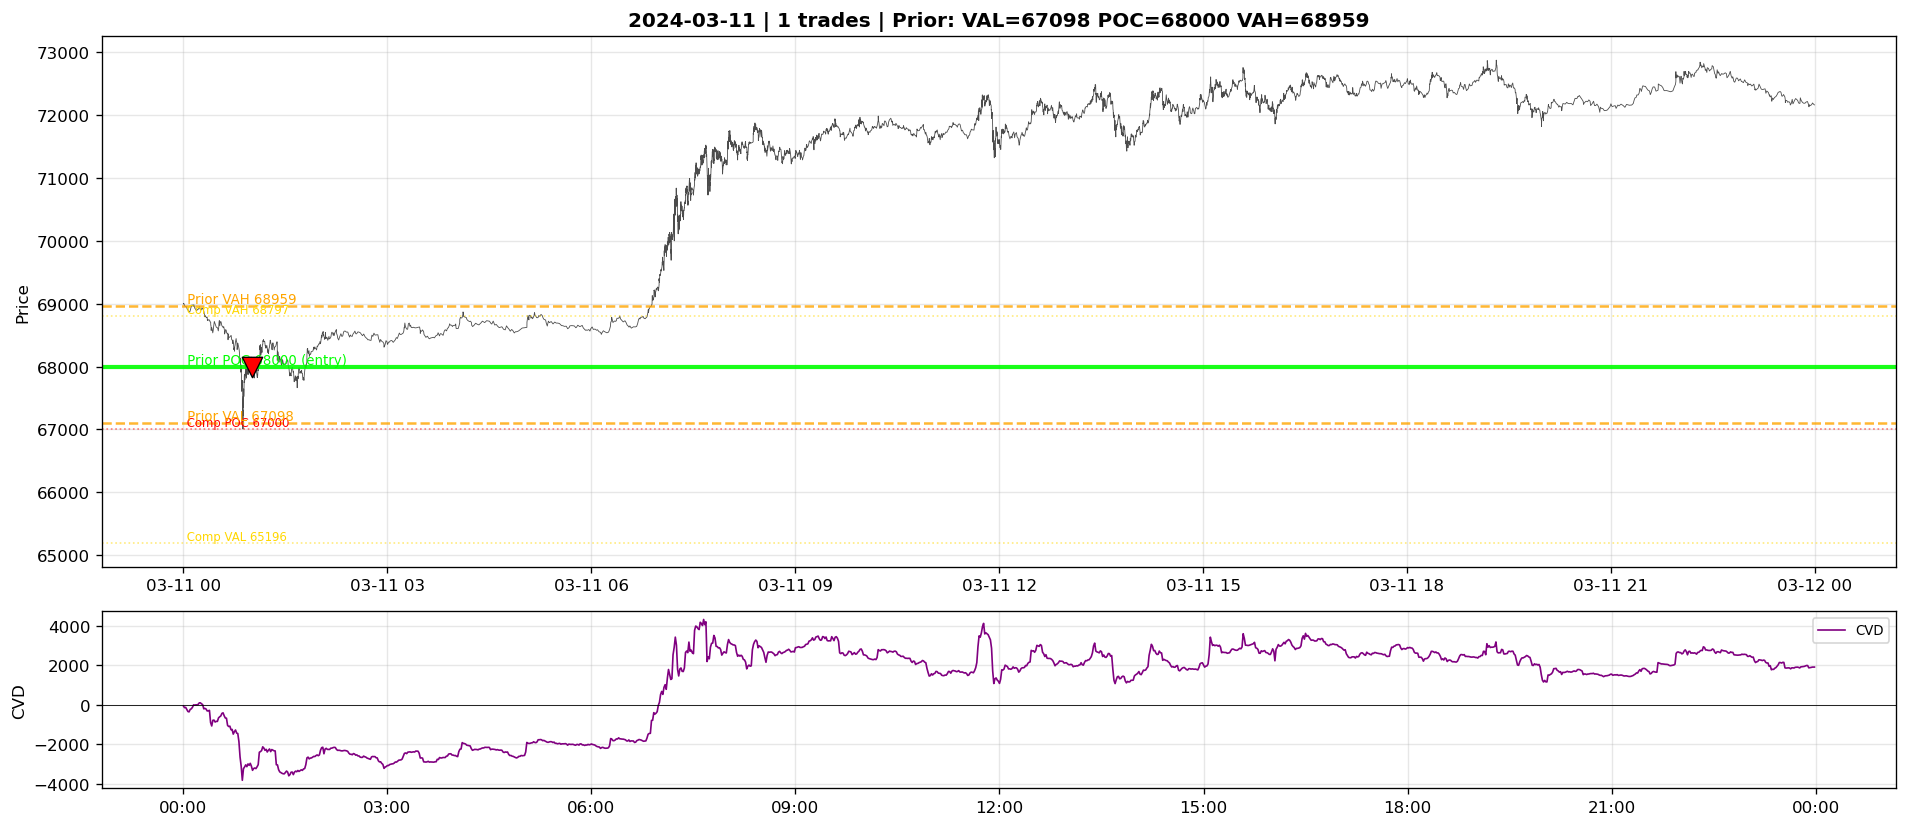

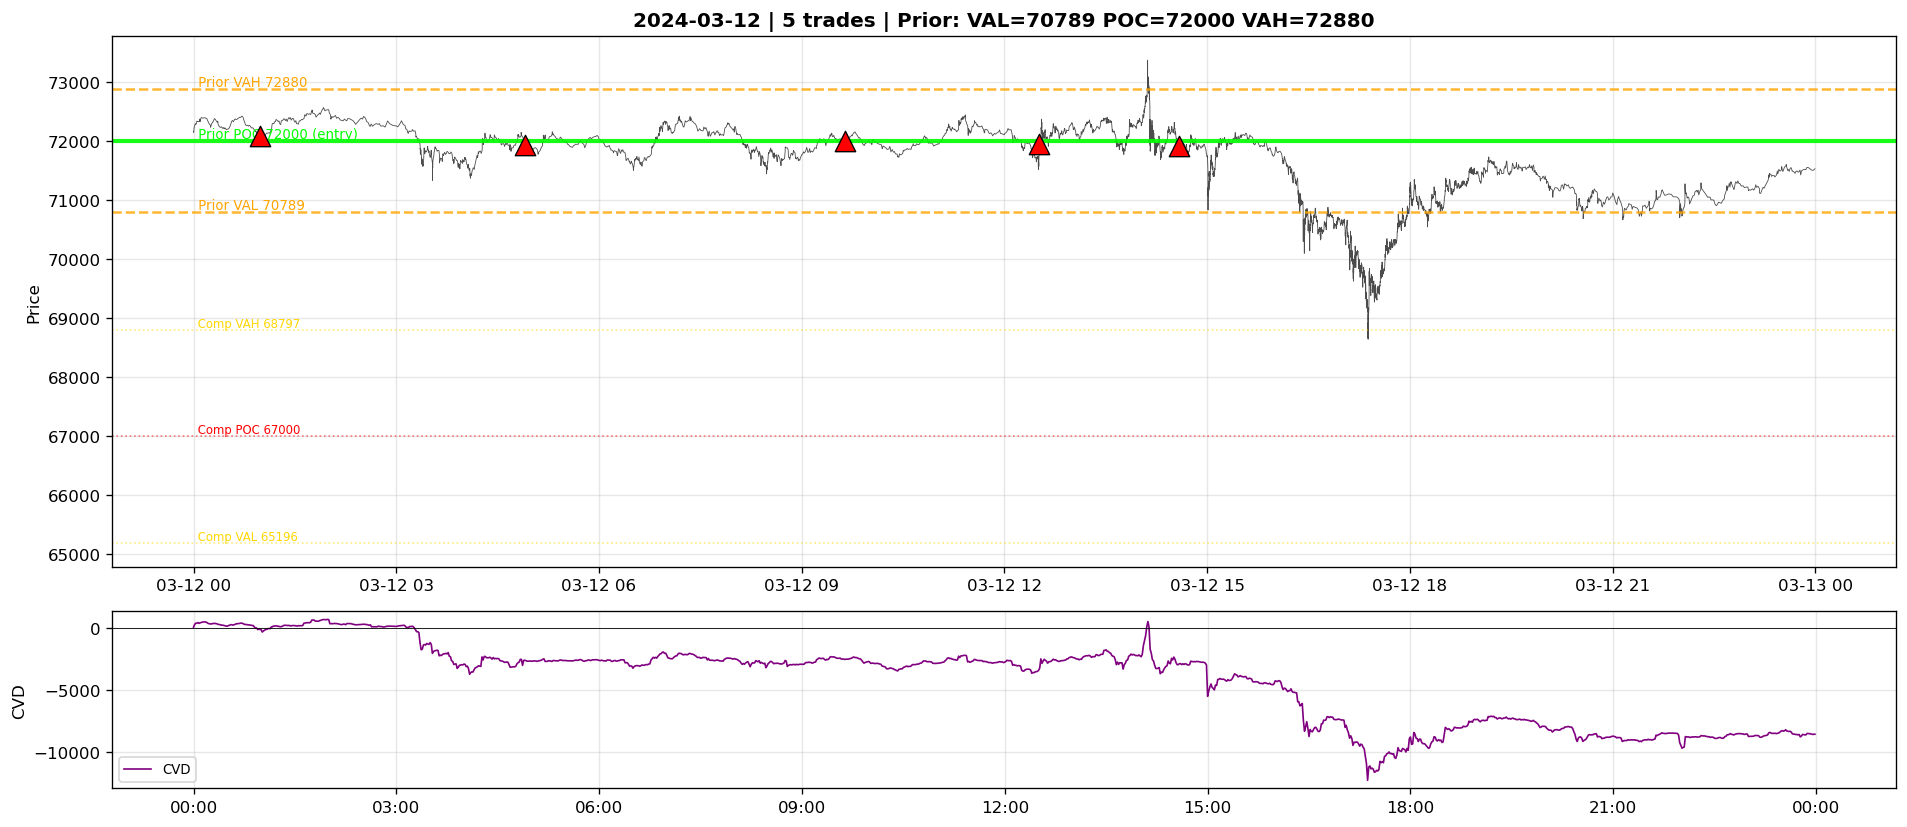

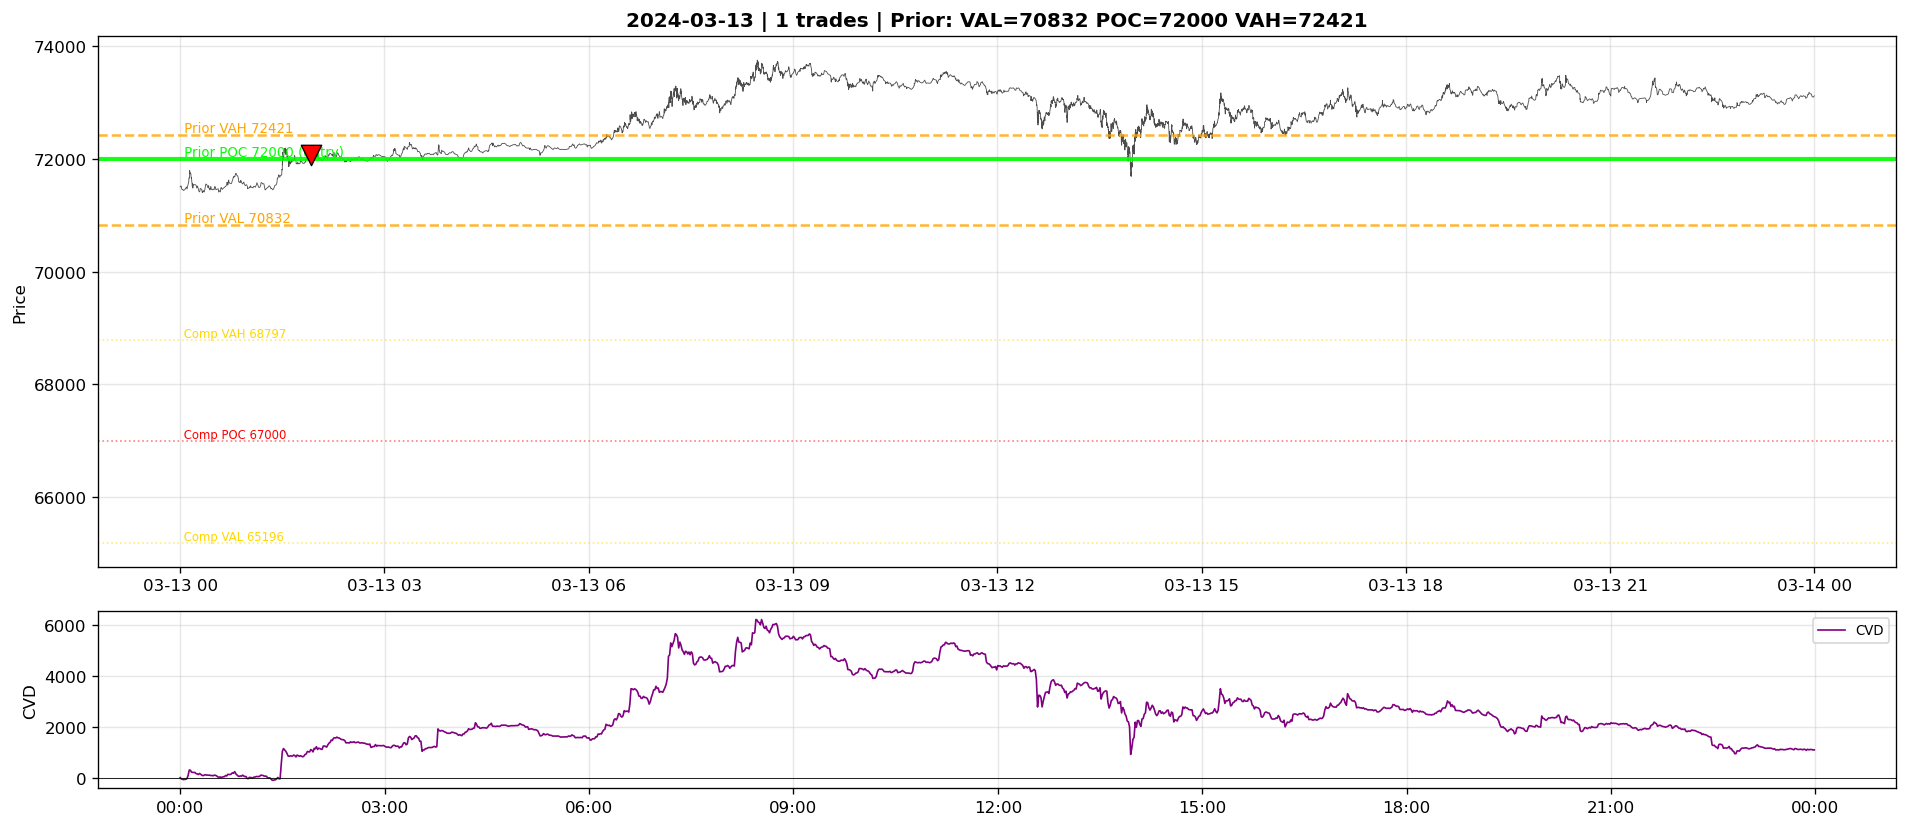

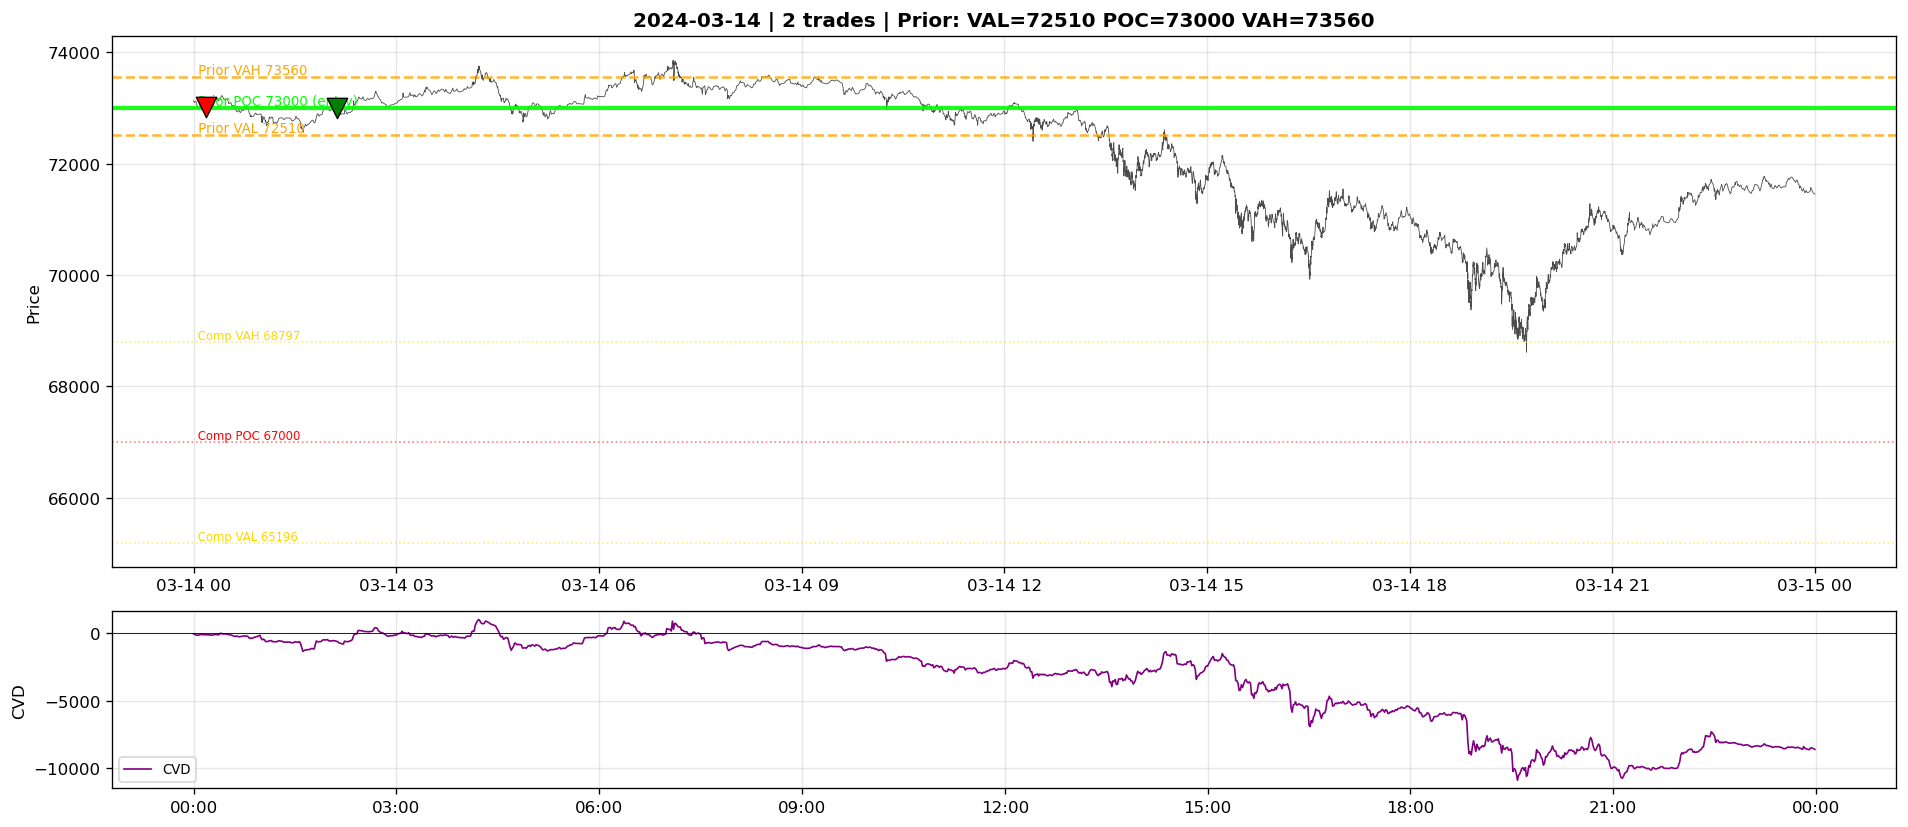

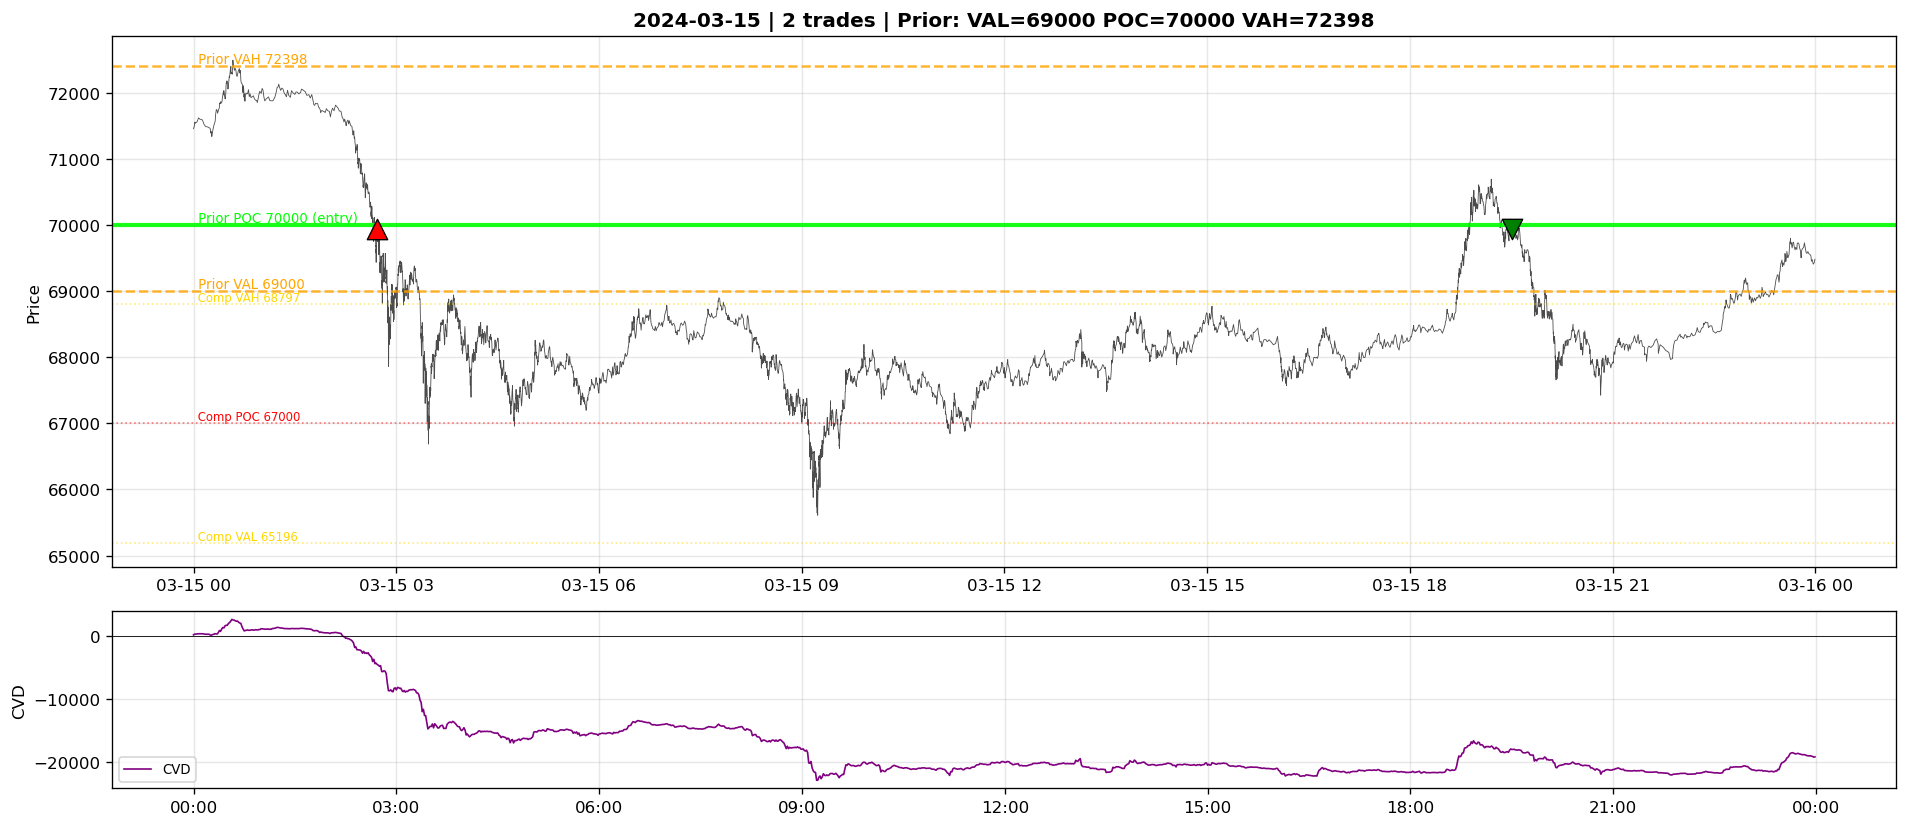

In [9]:
# === Charts with Correct Time Axes ===
for d in TEST_DAYS:
    r=results[d]
    tr=r['trades']
    ev=r['events']
    pp=r['prior_prof']
    
    times, prices = [], []
    for e in ev:
        if e['t']=='tr':
            times.append(pd.Timestamp(e['ts'],unit='ms'))
            prices.append(e['p'])
    if not times: continue
    step=max(1,len(times)//5000)
    
    fig,axes=plt.subplots(2,1,figsize=(16,7),gridspec_kw={'height_ratios':[3,1]})
    ax1,ax2=axes
    
    ax1.plot(times[::step],prices[::step],'k-',lw=0.5,alpha=0.7)
    
    # Composite levels
    for label,px,color in [
        (f'Comp VAL {COMP_VAL:.0f}',COMP_VAL,'gold'),
        (f'Comp POC {COMP_POC:.0f}',COMP_POC,'red'),
        (f'Comp VAH {COMP_VAH:.0f}',COMP_VAH,'gold'),
    ]:
        ax1.axhline(px,color=color,lw=1,ls=':',alpha=0.5)
        ax1.text(times[0],px,f' {label}',fontsize=7,color=color,va='bottom')
    
    # Prior day levels — highlight POC as entry level
    for label,px,color in [
        (f'Prior VAL {pp["val"]:.0f}',pp['val'],'orange'),
        (f'Prior POC {pp["poc"]:.0f} (entry)',pp['poc'],'lime'),
        (f'Prior VAH {pp["vah"]:.0f}',pp['vah'],'orange'),
    ]:
        if label.startswith('Prior POC'):
            ax1.axhline(px,color=color,lw=2.5,ls='-',alpha=0.9)
        else:
            ax1.axhline(px,color=color,lw=1.5,ls='--',alpha=0.8)
        ax1.text(times[0],px,f' {label}',fontsize=8,color=color,va='bottom')
    
    if len(tr)>0:
        for _,r2 in tr.iterrows():
            t_entry=pd.Timestamp(r2['ts_entry'],unit='ms') if r2['ts_entry'] else times[len(times)//2]
            col='green' if r2['pnl_pct']>0 else 'red'
            mk='^' if r2['side']=='LONG' else 'v'
            ax1.scatter(t_entry,r2['entry'],marker=mk,color=col,s=150,
                       zorder=5,edgecolors='black',linewidth=0.8)
    
    ax1.set_title(f'{d} | {len(tr)} trades | Prior: VAL={pp["val"]:.0f} POC={pp["poc"]:.0f} VAH={pp["vah"]:.0f}',
                  fontweight='bold')
    ax1.set_ylabel('Price'); ax1.grid(alpha=0.3)
    
    # CVD
    mdeltas={}
    for e in ev:
        if e['t']=='tr':
            m=e['ts']//60_000
            mdeltas[m]=mdeltas.get(m,0)+(-e['q'] if e['b'] else e['q'])
    if mdeltas:
        mt=sorted(mdeltas.keys()); mv=[mdeltas[m] for m in mt]
        ml=[pd.Timestamp(m*60_000,unit='ms') for m in mt]
        cvd_line=np.cumsum(mv)
        ax2.plot(ml,cvd_line,color='purple',lw=1,label='CVD')
        ax2.axhline(0,color='black',lw=0.5)
        ax2.set_ylabel('CVD'); ax2.grid(alpha=0.3); ax2.legend(fontsize=8)
    
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    plt.tight_layout(); plt.show()

---
## Analysis

- **v7 Change**: Entry at prior day **POC** instead of VAL/VAH
- **Direction from CVD divergence**: Absorption → LONG, Exhaustion → SHORT
- **Composite Profile**: 5-day background only (no bias filter)
- **Dynamic Sizing**: 2% account risk, stop at absorption bar low/high or 2% fixed
- **Targets**: prior VAH (longs) / prior VAL (shorts)